<a href="https://colab.research.google.com/github/lmaas37/FDD-Week-1/blob/main/01a_cx_gaussian_distributions_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Distributions for Store-Demand Modelling

## The situation

You run the inventory for **one product** in a store. Every day you record how many units
were **sold**. You would like a *model of daily demand* so you can answer practical questions:

- What is a **typical** day? How much does it swing around?
- How many units should we **stock** so we rarely run out?
- Some days are special — **promotions**, or days we **advertised the night before**. Do they
  follow the same pattern, or a different one?

The single most useful tool for "a spread of values around a typical one" is the
**Gaussian** (normal) distribution — the bell curve. In this notebook you will:

1. **Fit one Gaussian** and learn when it is (and isn't) the right model.
2. Discover the data hides **several regimes**, and that one bell is not enough.
3. Un-mix them automatically with a **Mixture of Gaussians**.
4. Turn the fitted bells into **decisions**: stock levels, stock-out risk, confidence intervals.

## What you have to work with

One row per day, over several years:

| column | meaning |
|---|---|
| `date` | the calendar day |
| `day_of_week` | Monday … Sunday |
| `is_promotion_day` | 1 if the product was on promotion that day |
| `advertisement_the_night_before` | 1 if we ran an ad the previous evening |
| `sales` | **units sold that day** — the quantity we want to model |

A useful quirk of this store: **Tuesdays never have a promotion and are never preceded by an
ad.** That will give us a clean, controlled slice to start from.

In [ ]:
#@title 🗺️ Roadmap: from one bell curve to stocking decisions { display-mode: "form" }
from IPython.display import HTML, display

display(HTML(r'''
<style>
.rm{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border-radius:18px;padding:20px 16px;margin:8px 0;border:1px solid #ecebff}
.rm-h{font-size:20px;font-weight:800;color:#3b2d6b;margin:0 0 4px}
.rm-s{font-size:12px;color:#6b6685;margin:0 0 16px}
.rm-row{display:flex;align-items:stretch;flex-wrap:wrap;gap:0}
.rm-step{flex:1 1 160px;min-width:160px;text-align:center;padding:0 6px}
.rm-ic{width:52px;height:52px;border-radius:50%;margin:0 auto 8px;display:flex;align-items:center;
       justify-content:center;font-size:23px;color:#fff;box-shadow:0 6px 14px rgba(102,126,234,.35)}
.rm-t{font-weight:800;font-size:13.5px;color:#2c2350}
.rm-q{font-size:11px;color:#6b6685;margin-top:3px;font-style:italic;line-height:1.3}
.rm-d{font-size:10.5px;color:#8b86a6;margin-top:5px;line-height:1.3}
.rm-ar{display:flex;align-items:center;font-size:18px;color:#b9a9e6;flex:0 0 14px}
</style>
<div class="rm">
  <div class="rm-h">🗺️ Four steps, one product</div>
  <div class="rm-s">Each step models the demand a little more honestly than the last.</div>
  <div class="rm-row">
    <div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,#667eea,#667eeacc)">🔔</div>
      <div class="rm-t">One Gaussian</div><div class="rm-q">what is a typical day?</div>
      <div class="rm-d">fit a bell curve to a clean slice (Tuesdays)</div></div>
    <div class="rm-ar">➜</div>
    <div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,#8a6fe0,#8a6fe0cc)">🔀</div>
      <div class="rm-t">Two regimes</div><div class="rm-q">why is one bell not enough?</div>
      <div class="rm-d">promotions are a different distribution</div></div>
    <div class="rm-ar">➜</div>
    <div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,#b06fd0,#b06fd0cc)">🎛️</div>
      <div class="rm-t">Mixture of Gaussians</div><div class="rm-q">how many regimes are there?</div>
      <div class="rm-d">let sklearn find all three of them</div></div>
    <div class="rm-ar">➜</div>
    <div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,#db6fa9,#db6fa9cc)">📦</div>
      <div class="rm-t">Risk &amp; stock</div><div class="rm-q">how many units to keep?</div>
      <div class="rm-d">quantiles, stock-out probability, intervals</div></div>
  </div>
</div>'''))

In [ ]:
#@title Setup { display-mode: "form" }
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture
from IPython.display import HTML, display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PURPLE, PURPLE2 = '#667eea', '#764ba2'
GREEN, RED, AMBER = '#39b36a', '#e0796d', '#e0a23c'
C_NORMAL, C_AD, C_PROMO = PURPLE, AMBER, RED   # colour per regime, used throughout
RANDOM_STATE = 0

In [ ]:
#@title Define the dataset builder (offline fallback) { display-mode: "form" }
# The data normally comes from the course repo (next cell). This builder reproduces the
# EXACT same sales.csv from scratch, so the notebook still runs if the repo is unreachable.
DOW = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
REGIMES   = ['normal', 'advertised', 'promotion']       # the three latent demand regimes
BASE_MEAN = {'normal': 100.0, 'advertised': 150.0, 'promotion': 215.0}
BASE_SD   = {'normal': 11.0,  'advertised': 14.0,  'promotion': 20.0}

def build_sales(n_days=2184, seed=42, start='2018-01-01', weekend_bump=15.0):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start=start, periods=n_days, freq='D')
    dow_idx = dates.dayofweek.to_numpy()                # Mon=0 .. Sun=6
    is_tuesday = dow_idx == 1
    is_weekend = dow_idx >= 5
    promo_p = np.array([0.05, 0.00, 0.05, 0.07, 0.25, 0.30, 0.13])   # promo chance by weekday
    is_promotion = (rng.random(n_days) < promo_p[dow_idx]) & ~is_tuesday
    eligible_ad = ~is_promotion & ~is_tuesday
    is_advertised = (rng.random(n_days) < 0.28) & eligible_ad
    regime = np.where(is_promotion, 'promotion',
                      np.where(is_advertised, 'advertised', 'normal'))
    means = np.array([BASE_MEAN[r] for r in regime])
    sds   = np.array([BASE_SD[r] for r in regime])
    sales = rng.normal(means, sds) + weekend_bump * is_weekend
    sales = np.clip(np.round(sales), 0, None).astype(int)
    return pd.DataFrame({
        'date': dates.strftime('%Y-%m-%d'),
        'day_of_week': np.array(DOW)[dow_idx],
        'is_promotion_day': is_promotion.astype(int),
        'advertisement_the_night_before': is_advertised.astype(int),
        'sales': sales})

REGIMES  # (defined; the data is loaded in the next cell)

In [ ]:
#@title Load the store-demand data { display-mode: "form" }
print('Building the dataset...', end=' ')
df = build_sales()
print('Done')

df['date'] = pd.to_datetime(df['date'])
# The regime is FULLY determined by the two flags (they are mutually exclusive by design).
# We only use this "known truth" to check the unsupervised mixture model later in Part 3.
df['true_regime'] = np.where(df.is_promotion_day == 1, 'promotion',
                     np.where(df.advertisement_the_night_before == 1, 'advertised', 'normal'))

tuesdays = df[df.day_of_week == 'Tuesday']
promo    = df[df.is_promotion_day == 1]
rest     = df[df.is_promotion_day == 0]
print('total days', len(df), '| Tuesdays', len(tuesdays),
      '| promo days', len(promo), '| non-promo days', len(rest))
df.head(4)

Each row is one **day**. `sales` is the number we want to model; the flags tell us whether
that day was special. Notice we also added a helper column `true_regime` — since the two flags
never overlap, every day is exactly one of `normal`, `advertised`, or `promotion`. We keep it
hidden until **Part 3**, where we check whether a model can rediscover it *from the sales alone*.

# Part 1 — One Gaussian: what does a "typical day" look like?

A **Gaussian** (normal distribution) is the classic bell curve. It is completely described by
just **two numbers**:

- the **mean** $\mu$ — where the bell is centred (the typical value),
- the **standard deviation** $\sigma$ — how wide the bell is (how much days swing around $\mu$).

Its formula — the height of the curve at a value $x$ — is

$$f(x)\;=\;\frac{1}{\sigma\sqrt{2\pi}}\;\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).$$

The single most useful fact about a Gaussian is the **68–95–99.7 rule**: about 68% of days fall
within $\pm1\sigma$ of the mean, 95% within $\pm2\sigma$, and 99.7% within $\pm3\sigma$. Run the
visualization below and change $\sigma$ to see it.

In [ ]:
#@title 🔔 Anatomy of a Gaussian — press the buttons to change the spread { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.ga{font-family:system-ui,Segoe UI,Roboto,sans-serif;max-width:640px;margin:6px 0;
    background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:16px;padding:16px 18px}
.ga h3{margin:0 0 2px;color:#3b2d6b;font-size:17px}
.ga p{margin:0 0 10px;color:#6b6685;font-size:12px}
.ga-btns{display:flex;gap:8px;margin:0 0 8px;flex-wrap:wrap}
.ga-btn{border:1px solid #d9d4f5;background:#fff;color:#4a3f86;border-radius:999px;
        padding:6px 14px;font-size:12px;font-weight:700;cursor:pointer;transition:.15s}
.ga-btn:hover{background:#efeaff}
.ga-btn.on{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;border-color:transparent}
.ga-legend{display:flex;gap:14px;flex-wrap:wrap;margin-top:8px;font-size:11.5px;color:#4a4463}
.ga-legend b{font-weight:800}
.ga-sw{display:inline-block;width:11px;height:11px;border-radius:3px;margin-right:5px;vertical-align:-1px}
</style>
<div class="ga">
  <h3>🔔 One product, one bell</h3>
  <p>Same mean (&mu; = 100 units). The buttons change only the spread &sigma;. The shaded bands are the 68 / 95 / 99.7% rule.</p>
  <div class="ga-btns">
    <button class="ga-btn" id="ga-b0" onclick="gaSet(0)">Steady product (&sigma; = 8)</button>
    <button class="ga-btn on" id="ga-b1" onclick="gaSet(1)">Typical (&sigma; = 14)</button>
    <button class="ga-btn" id="ga-b2" onclick="gaSet(2)">Volatile (&sigma; = 24)</button>
  </div>
  <svg id="ga-svg" viewBox="0 0 600 250" width="100%" style="max-width:600px"></svg>
  <div class="ga-legend">
    <span><span class="ga-sw" style="background:#667eea"></span><b>&plusmn;1&sigma;</b> &rarr; 68% of days</span>
    <span><span class="ga-sw" style="background:#9d8be8"></span><b>&plusmn;2&sigma;</b> &rarr; 95% of days</span>
    <span><span class="ga-sw" style="background:#cfc6f2"></span><b>&plusmn;3&sigma;</b> &rarr; 99.7% of days</span>
  </div>
</div>
<script>
(function(){
  var SIG=[8,14,24], cur=1, W=600,H=250,padB=34,padT=12,mu=100,vmin=40,vmax=160;
  var svg=document.getElementById('ga-svg');
  function px(v){return (v-vmin)/(vmax-vmin)*W;}
  function draw(s){
    var peak=1.0, py=function(v){var z=(v-mu)/s;return Math.exp(-0.5*z*z);};
    var yPix=function(p){return padT+(1-p)*(H-padB-padT);};
    var bands=[[3,'#cfc6f2'],[2,'#9d8be8'],[1,'#667eea']], out='';
    bands.forEach(function(b){var k=b[0];var x0=px(mu-k*s),x1=px(mu+k*s);
      out+='<rect x="'+x0.toFixed(1)+'" y="'+padT+'" width="'+(x1-x0).toFixed(1)+'" height="'+(H-padB-padT)+'" fill="'+b[1]+'" opacity="0.5"/>';});
    var d='';for(var v=vmin;v<=vmax;v+=0.8){var X=px(v),Y=yPix(py(v));d+=(v===vmin?'M':'L')+X.toFixed(1)+' '+Y.toFixed(1);}
    out+='<path d="'+d+'" fill="none" stroke="#2c2350" stroke-width="2.4"/>';
    out+='<line x1="'+px(mu)+'" y1="'+padT+'" x2="'+px(mu)+'" y2="'+(H-padB)+'" stroke="#2c2350" stroke-dasharray="4 4" stroke-width="1.2"/>';
    out+='<line x1="0" y1="'+(H-padB)+'" x2="'+W+'" y2="'+(H-padB)+'" stroke="#b9b3d0" stroke-width="1"/>';
    [mu-3*s,mu-2*s,mu-s,mu,mu+s,mu+2*s,mu+3*s].forEach(function(v){
      if(v<vmin||v>vmax)return;out+='<text x="'+px(v)+'" y="'+(H-padB+16)+'" font-size="10.5" fill="#6b6685" text-anchor="middle">'+Math.round(v)+'</text>';});
    out+='<text x="'+px(mu)+'" y="'+(padT+12)+'" font-size="12" font-weight="700" fill="#2c2350" text-anchor="middle">&mu;</text>';
    out+='<text x="'+(W-6)+'" y="'+(H-6)+'" font-size="10.5" fill="#8b86a6" text-anchor="end">units sold</text>';
    svg.innerHTML=out;
  }
  window.gaSet=function(i){cur=i;for(var k=0;k<3;k++)document.getElementById('ga-b'+k).className='ga-btn'+(k===i?' on':'');draw(SIG[i]);};
  draw(SIG[cur]);
})();
</script>'''))

### First, look at the data

Before assuming any shape, plot it. Below: the **whole history** of daily sales as a histogram,
and a short window as a time series so you can see the day-to-day pattern.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(df.sales, bins=40, color=PURPLE, alpha=.75, edgecolor='white', linewidth=.4)
ax[0].set_title('All daily sales (every day in the record)', fontsize=11)
ax[0].set_xlabel('units sold'); ax[0].set_ylabel('number of days')

window = df.iloc[:120]
ax[1].plot(window.date, window.sales, color=PURPLE, lw=1.1)
spikes = window[window.is_promotion_day == 1]
ax[1].scatter(spikes.date, spikes.sales, color=RED, s=22, zorder=3, label='promotion day')
ax[1].set_title('First ~4 months, day by day', fontsize=11)
ax[1].set_xlabel('date'); ax[1].set_ylabel('units sold'); ax[1].legend(fontsize=9)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

print(df.sales.describe().round(1))

The histogram is **not** a clean bell: it has a long tail to the right and looks lumpy. The
time series hints at why — the red **promotion** days spike far above the rest. Mixing different
kinds of days into one pile blurs the picture.

**The fix: control the conditions.** Tuesdays never have a promotion and are never preceded by an
ad — so Tuesday sales should be one single, undisturbed regime. Let's fit a Gaussian *there* first.

### Exercise 1 — fit your first Gaussian (on Tuesdays)

Fitting a Gaussian means finding the $\mu$ and $\sigma$ that best match the data. The
maximum-likelihood answer is refreshingly simple: **$\mu$ is the sample mean and $\sigma$ is the
sample standard deviation.** Implement the two core primitives, then fit and plot.

In [ ]:
# 🎯 YOUR TURN — Exercise 1: the Gaussian density and the fit.
#
# 💭 Think first: a Gaussian is fully described by mu (its centre) and sigma (its spread).
#    Density at x:   f(x) = 1 / (sigma * sqrt(2*pi)) * exp( -(x - mu)^2 / (2 * sigma^2) ).
#    Best-fit (maximum likelihood):  mu = mean of the data,  sigma = std of the data.
#
# 🎯 Fill in the two returns. Tools: np.exp, np.sqrt, np.pi ; x.mean(), x.std().
def gaussian_pdf(x, mu, sigma):
    return ...

def fit_gaussian(data):
    x = np.asarray(data, dtype=float)
    return ...          # (mu, sigma): the mean and the (population) standard deviation

# already written for you: fit on Tuesdays and plot
mu_tue, sig_tue = fit_gaussian(tuesdays.sales)
print(f'Tuesday demand:  mu = {mu_tue:.1f} units,  sigma = {sig_tue:.1f} units')

xs = np.linspace(tuesdays.sales.min() - 10, tuesdays.sales.max() + 10, 300)
plt.figure(figsize=(7, 3.6))
plt.hist(tuesdays.sales, bins=22, density=True, color=PURPLE, alpha=.55, edgecolor='white', linewidth=.4)
plt.plot(xs, gaussian_pdf(xs, mu_tue, sig_tue), color=PURPLE2, lw=2.4,
         label=f'fitted Gaussian  N({mu_tue:.0f}, {sig_tue:.0f})')
plt.title('Tuesdays: one clean regime -> one clean bell', fontsize=11)
plt.xlabel('units sold'); plt.ylabel('density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

That is a **good fit** — the bell sits neatly on the histogram, because Tuesdays are a single
controlled regime. Now watch what happens when we fit the *same way* on **all days at once**.

In [ ]:
mu_all, sig_all = fit_gaussian(df.sales)
print(f'All-days fit:  mu = {mu_all:.1f},  sigma = {sig_all:.1f}')

xs = np.linspace(df.sales.min() - 10, df.sales.max() + 10, 400)
plt.figure(figsize=(7, 3.6))
plt.hist(df.sales, bins=45, density=True, color=AMBER, alpha=.5, edgecolor='white', linewidth=.4)
plt.plot(xs, gaussian_pdf(xs, mu_all, sig_all), color=RED, lw=2.4,
         label=f'fitted Gaussian  N({mu_all:.0f}, {sig_all:.0f})')
plt.title('All days: one bell cannot cover the lumps and the tail', fontsize=11)
plt.xlabel('units sold'); plt.ylabel('density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

The single bell **misses badly**: it sits too wide, its peak is too low, and it ignores the
bump on the right. The data is telling us it is **not one regime but several**. That is the cue
for Part 2.

# Part 2 — More than one regime

The obvious special day is a **promotion**. Let's separate the days into *promotion* vs
*everything else* and fit a Gaussian to each.

### Exercise 2 — fit one Gaussian per group

Write a small reusable helper `overlay_gaussian` that (1) fits a Gaussian to a slice of sales,
(2) draws the histogram, and (3) draws the fitted bell on top — returning $(\mu, \sigma)$. Then
apply it to promotion days and to all other days.

In [ ]:
# 🎯 YOUR TURN — Exercise 2: a reusable "fit + overlay" helper.
#
# 💭 Think first: for a slice of sales, (1) fit a Gaussian, (2) draw its histogram
#    (density=True so it shares the pdf's scale), (3) draw the fitted bell on top.
#    Return (mu, sigma) so the caller can reuse the numbers later.
#
# 🎯 Fill in the body. Tools: fit_gaussian(data) ; ax.hist(data, bins=bins, density=True, ...) ;
#    xs = np.linspace(np.min(data)-10, np.max(data)+10, 300) ; ax.plot(xs, gaussian_pdf(xs, mu, sigma), ...).
def overlay_gaussian(ax, data, color, label, bins=22):
    mu, sigma = ...                       # fit the Gaussian to this slice
    ...                                   # ax.hist the data (density=True), colour=color
    xs = ...                              # a smooth x-range spanning the data
    ...                                   # ax.plot the fitted gaussian_pdf over xs, label=f'{label}: N({mu:.0f}, {sigma:.0f})'
    ax.set_xlabel('units sold'); ax.legend(fontsize=9)
    return mu, sigma

# already written for you: apply to promotion days and all other days
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
mu_p, sig_p = overlay_gaussian(ax[0], promo.sales, C_PROMO, 'promotion days')
ax[0].set_title('Promotion days: a clean bell (far to the right)', fontsize=11); ax[0].set_ylabel('density')
mu_r, sig_r = overlay_gaussian(ax[1], rest.sales, C_NORMAL, 'all other days', bins=40)
ax[1].set_title('All other days: better... but still not clean', fontsize=11)
plt.tight_layout(); plt.show()

print(f'promotion days : mu = {mu_p:.1f}, sigma = {sig_p:.1f}')
print(f'all other days : mu = {mu_r:.1f}, sigma = {sig_r:.1f}')

In [ ]:
# Superpose BOTH fitted bells on the REAL, full histogram. Each bell is weighted by how often
# that kind of day happens (its share of all days), so their SUM is a first two-regime model of
# all daily sales -- compare the dashed sum to the single bell we fitted in Part 1.
w_promo = len(promo) / len(df)
w_rest  = len(rest) / len(df)
xs = np.linspace(df.sales.min() - 10, df.sales.max() + 10, 500)
bell_promo = w_promo * gaussian_pdf(xs, mu_p, sig_p)
bell_rest  = w_rest  * gaussian_pdf(xs, mu_r, sig_r)

plt.figure(figsize=(8, 4))
plt.hist(df.sales, bins=50, density=True, color='#d9d4f5', alpha=.7, edgecolor='white', linewidth=.3,
         label='all daily sales (real)')
plt.plot(xs, bell_rest,  color=C_NORMAL, lw=2.2, label=f'all other days  ({w_rest:.0%} of days)')
plt.plot(xs, bell_promo, color=C_PROMO,  lw=2.2, label=f'promotion days  ({w_promo:.0%} of days)')
plt.plot(xs, bell_rest + bell_promo, color='#2c2350', lw=2.4, ls='--', label='sum of the two bells')
plt.title('Two weighted bells, superposed on the real demand', fontsize=12)
plt.xlabel('units sold'); plt.ylabel('density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

Weighting each bell by how common that kind of day is and adding them gives a **first
two-regime model** of *all* sales — already far closer to the real histogram than the single bell
from Part 1, and the far-right promotion hump is now captured. But look at the left side: the
dashed sum still doesn't sit perfectly, because "all other days" is itself a blend. That is
exactly the loose end we chase in Part 3.

Two takeaways:

- **Promotion days are a beautiful single Gaussian** — a genuine, distinct regime living far to
  the right.
- **"All other days" is much better than the all-days fit, but still not clean** — the bell
  overshoots on the left and there is a shoulder around the middle. Something *else* is still
  mixed in there.

That "something else" is a third regime: days we **advertised the night before**. Rather than
keep splitting by hand, we introduce the idea that handles any number of regimes at once: a
**Mixture of Gaussians**.

In [ ]:
#@title 🎛️ What a Mixture of Gaussians is — click to reveal the hidden bells { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.mx{font-family:system-ui,Segoe UI,Roboto,sans-serif;max-width:660px;margin:6px 0;
    background:linear-gradient(135deg,#f6f8ff,#fbf5ff);border:1px solid #ecebff;border-radius:16px;padding:16px 18px}
.mx h3{margin:0 0 2px;color:#3b2d6b;font-size:17px}
.mx p{margin:0 0 10px;color:#6b6685;font-size:12px}
.mx-btns{display:flex;gap:8px;margin:0 0 8px;flex-wrap:wrap}
.mx-btn{border:1px solid #d9d4f5;background:#fff;color:#4a3f86;border-radius:999px;
        padding:6px 14px;font-size:12px;font-weight:700;cursor:pointer;transition:.15s}
.mx-btn:hover{background:#efeaff}
.mx-btn.on{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;border-color:transparent}
.mx-note{font-size:12px;color:#4a4463;background:#fff;border:1px solid #ece9fb;border-radius:10px;padding:9px 12px;margin-top:8px}
</style>
<div class="mx">
  <h3>🎛️ A mixture is a weighted sum of bells</h3>
  <p>The lumpy demand you saw is really <b>several</b> Gaussians added together, each weighted by how often that kind of day happens. A mixture model does the reverse: given the blend, it recovers the hidden bells.</p>
  <div class="mx-btns">
    <button class="mx-btn on" id="mx-b0" onclick="mxSet(0)">What you observe (the blend)</button>
    <button class="mx-btn" id="mx-b1" onclick="mxSet(1)">What is really there (3 bells)</button>
  </div>
  <svg id="mx-svg" viewBox="0 0 640 250" width="100%" style="max-width:640px"></svg>
  <div class="mx-note" id="mx-note"></div>
</div>
<script>
(function(){
  var W=640,H=250,padB=30,padT=12,vmin=50,vmax=280;
  var comps=[{mu:108,s:12,w:0.66,c:'#667eea',n:'normal days'},
             {mu:150,s:14,w:0.21,c:'#e0a23c',n:'advertised night before'},
             {mu:222,s:20,w:0.13,c:'#e0796d',n:'promotion days'}];
  var svg=document.getElementById('mx-svg'),note=document.getElementById('mx-note');
  function px(v){return (v-vmin)/(vmax-vmin)*W;}
  function comp(v,c){var z=(v-c.mu)/c.s;return c.w/(c.s*Math.sqrt(2*Math.PI))*Math.exp(-0.5*z*z);}
  var ymax=0;for(var v=vmin;v<=vmax;v+=1){var s=0;comps.forEach(function(c){s+=comp(v,c);});if(s>ymax)ymax=s;}
  function yPix(y){return padT+(1-y/ymax)*(H-padB-padT);}
  function path(fn){var d='';for(var v=vmin;v<=vmax;v+=1){var X=px(v),Y=yPix(fn(v));d+=(v===vmin?'M':'L')+X.toFixed(1)+' '+Y.toFixed(1);}return d;}
  function axis(){var o='<line x1="0" y1="'+(H-padB)+'" x2="'+W+'" y2="'+(H-padB)+'" stroke="#b9b3d0" stroke-width="1"/>';
    o+='<text x="'+(W-6)+'" y="'+(H-6)+'" font-size="10.5" fill="#8b86a6" text-anchor="end">units sold</text>';return o;}
  function draw(mode){
    var out=axis();
    if(mode===0){
      out+='<path d="'+path(function(v){var s=0;comps.forEach(function(c){s+=comp(v,c);});return s;})+' L'+px(vmax)+' '+(H-padB)+' L'+px(vmin)+' '+(H-padB)+' Z" fill="#667eea" opacity="0.18"/>';
      out+='<path d="'+path(function(v){var s=0;comps.forEach(function(c){s+=comp(v,c);});return s;})+'" fill="none" stroke="#2c2350" stroke-width="2.6"/>';
      note.innerHTML='One lumpy curve. You can see bumps, but not how many regimes there are or where each is centred.';
    } else {
      comps.forEach(function(c){
        out+='<path d="'+path(function(v){return comp(v,c);})+' L'+px(vmax)+' '+(H-padB)+' L'+px(vmin)+' '+(H-padB)+' Z" fill="'+c.c+'" opacity="0.16"/>';
        out+='<path d="'+path(function(v){return comp(v,c);})+'" fill="none" stroke="'+c.c+'" stroke-width="2.4"/>';
        out+='<text x="'+px(c.mu)+'" y="'+(yPix(comp(c.mu,c))-6)+'" font-size="10.5" font-weight="700" fill="'+c.c+'" text-anchor="middle">'+Math.round(c.w*100)+'%</text>';
      });
      note.innerHTML='Three bells: <b style="color:#667eea">normal</b> (~66% of days), <b style="color:#e0a23c">advertised</b> (~21%), <b style="color:#e0796d">promotion</b> (~13%). Each has its own &mu;, &sigma; and weight.';
    }
    svg.innerHTML=out;
  }
  window.mxSet=function(i){document.getElementById('mx-b0').className='mx-btn'+(i===0?' on':'');
    document.getElementById('mx-b1').className='mx-btn'+(i===1?' on':'');draw(i);};
  draw(0);
})();
</script>'''))

# Part 3 — Let a Mixture of Gaussians find all the regimes

A **Gaussian Mixture Model (GMM)** assumes the data comes from $K$ hidden Gaussians. Given only
the `sales` numbers, `sklearn` finds, for each component, its **mean**, **standard deviation**,
and **weight** (how large a share of days it represents). It also tells us, for each day, which
component it most likely came from.

We suspect **three** regimes (normal / advertised / promotion), so we fit with `n_components=3`.

### Exercise 3 — fit the mixture and name the regimes

`GaussianMixture` doesn't know our labels — it returns components in an arbitrary order. Fit it,
then **sort the components by their mean** so we can line them up with normal < advertised <
promotion.

In [ ]:
# 🎯 YOUR TURN — Exercise 3: fit a 3-component GMM and map components to regimes.
#
# 💭 Think first: GaussianMixture finds K hidden bells from the sales ALONE. It returns them in
#    an ARBITRARY order, so we sort the components by their mean to line them up with the real
#    order  normal < advertised < promotion.
#
# 🎯 Fill in the two blanks. Tools: GaussianMixture(n_components=3, n_init=5,
#    random_state=RANDOM_STATE).fit(X) ; np.argsort(means).
X = df.sales.to_numpy().reshape(-1, 1).astype(float)     # sklearn wants a 2-D column
gmm = ...                                                # fit a 3-component GaussianMixture on X

means = gmm.means_.ravel()
sigmas = np.sqrt(gmm.covariances_.ravel())
weights = gmm.weights_
order = ...                                              # indices that sort components by ASCENDING mean
names = ['normal', 'advertised', 'promotion']            # matches the sorted order

# already written for you: report, label every day, and score the recovery
print('Recovered components (sorted by mean):')
for rank, comp in enumerate(order):
    print(f'  {names[rank]:<11s}  mu = {means[comp]:6.1f}   sigma = {sigmas[comp]:5.1f}   '
          f'weight = {weights[comp]:.2f}')

comp_to_name = {comp: names[rank] for rank, comp in enumerate(order)}
df['gmm_regime'] = [comp_to_name[c] for c in gmm.predict(X)]

recovery = (df.gmm_regime == df.true_regime).mean()
print(f'\nUnsupervised recovery vs the known flags: {recovery:.1%} of days labelled correctly')

In [ ]:
# Visualize the fitted mixture on top of the data.
xs = np.linspace(df.sales.min() - 10, df.sales.max() + 10, 500)
plt.figure(figsize=(8, 4))
plt.hist(df.sales, bins=50, density=True, color='#d9d4f5', alpha=.7, edgecolor='white', linewidth=.3,
         label='all daily sales')
colors = {'normal': C_NORMAL, 'advertised': C_AD, 'promotion': C_PROMO}
mixture = np.zeros_like(xs)
for rank, comp in enumerate(order):
    pdf = weights[comp] * gaussian_pdf(xs, means[comp], sigmas[comp])
    mixture += pdf
    plt.plot(xs, pdf, color=colors[names[rank]], lw=2.2, label=f'{names[rank]}  ({weights[comp]:.0%})')
plt.plot(xs, mixture, color='#2c2350', lw=2.4, ls='--', label='mixture (sum)')
plt.title('Three Gaussians, discovered from the sales alone', fontsize=12)
plt.xlabel('units sold'); plt.ylabel('density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

The mixture nails it. Fitting **only** the `sales` column — never touching the flags — the GMM
recovered three components whose means line up with our three real regimes, and it labels the vast
majority of days correctly. The dashed sum now hugs the histogram that a single bell could not.

This is the payoff of Part 3: **you don't need to know the special days in advance.** The mixture
discovers the regimes, their typical demand, their variability, and how common they are.

# Part 4 — From bells to decisions: quantiles, stock-out risk, intervals

A fitted Gaussian is not just a picture — it answers **operational** questions exactly. Promotion
days are the risky ones (highest, most variable demand), so let's stock for them. We use the
promotion Gaussian $N(\mu_p, \sigma_p)$ from Part 2 with `scipy.stats.norm`:

- **Quantile / service level.** Stocking $S$ units covers demand whenever $\text{sales}\le S$.
  The stock level that covers a fraction $q$ of promo days is the **$q$-quantile**
  $S_q = \text{norm.ppf}(q,\ \mu_p,\ \sigma_p)$.
- **Stock-out probability.** For a chosen stock $S$, the chance of running out is the right-tail
  $P(\text{sales} > S) = 1 - \text{norm.cdf}(S,\ \mu_p,\ \sigma_p)$.
- **Central interval.** The band containing the middle 90% of promo days is
  $[\,\text{ppf}(0.05),\ \text{ppf}(0.95)\,]$.

### Exercise 4 — stock the shelf for a promotion

Compute the 95%-service stock level, the stock-out risk of the *current* plan (`current_stock`
below), and the 90% central demand interval.

In [ ]:
# 🎯 YOUR TURN — Exercise 4: turn the promotion Gaussian into stocking decisions.
#
# 💭 Think first: use scipy.stats.norm with the promotion fit (mu_p, sig_p from Exercise 2):
#    • stock covering a fraction q of days  = the q-quantile      -> stats.norm.ppf(q, mu, sigma)
#    • stock-out risk at a stock level S    = right tail P(x > S) -> 1 - stats.norm.cdf(S, mu, sigma)
#    • central 90% interval                 = [ppf(0.05), ppf(0.95)]
current_stock = 230       # what the store keeps on a promo day today
service = 0.95            # we want to satisfy demand on 95% of promo days

stock_for_service = ...   # stock level that covers `service` of promo days
stockout_now = ...        # probability of running out at current_stock
low, high = ...           # the middle-90% demand interval  (a tuple)

# already written for you: report
print(f'promotion demand ~ N({mu_p:.0f}, {sig_p:.0f})')
print(f'stock to cover 95% of promo days : {stock_for_service:.0f} units')
print(f'stock-out risk at current stock {current_stock}: {stockout_now:.1%} of promo days run out')
print(f'90% of promo days sell between {low:.0f} and {high:.0f} units')

In [ ]:
# Visualize the stock-out tail: the shaded area is the probability of running out.
xs = np.linspace(mu_p - 4 * sig_p, mu_p + 4 * sig_p, 400)
pdf = gaussian_pdf(xs, mu_p, sig_p)
plt.figure(figsize=(7.5, 3.8))
plt.plot(xs, pdf, color=C_PROMO, lw=2.4)
tail = xs >= current_stock
plt.fill_between(xs[tail], pdf[tail], color=RED, alpha=.45,
                 label=f'stock-out risk = {stockout_now:.1%}')
plt.axvline(current_stock, color=RED, ls='--', lw=1.6, label=f'current stock = {current_stock}')
plt.axvline(stock_for_service, color=GREEN, ls='--', lw=1.6, label=f'95% service = {stock_for_service:.0f}')
plt.title('Promotion-day demand: how much to stock, and the risk of running out', fontsize=11)
plt.xlabel('units sold'); plt.ylabel('density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

Now the model earns its keep. Reading the chart: today's stock leaves a visible red tail —
a real chance of selling out on a promo day. Pushing the stock up to the green line shrinks that
tail to 5%. And because the demand is Gaussian, we can state a crisp planning range: *90% of
promotion days will sell somewhere between the two edges of the central interval.* Same idea works
for any regime — just plug in that regime's $\mu$ and $\sigma$.

# Summary — one product, four steps

In [ ]:
#@title 🔔 The four steps at a glance { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.sm{font-family:system-ui,Segoe UI,Roboto,sans-serif;max-width:720px;margin:6px 0}
.sm-card{display:flex;align-items:stretch;gap:0;background:#fff;border:1px solid #ecebff;
         border-radius:14px;margin:10px 0;overflow:hidden;box-shadow:0 2px 10px rgba(80,60,160,.06)}
.sm-acc{flex:0 0 6px}
.sm-ic{flex:0 0 66px;display:flex;align-items:center;justify-content:center;font-size:26px;background:#faf9ff}
.sm-body{padding:11px 15px;flex:1}
.sm-top{display:flex;align-items:center;gap:9px;flex-wrap:wrap}
.sm-step{font-size:10.5px;font-weight:800;color:#fff;border-radius:999px;padding:2px 9px}
.sm-name{font-size:15px;font-weight:800;color:#2c2350}
.sm-chip{font-family:ui-monospace,Menlo,monospace;font-size:11px;color:#4a3f86;background:#efeaff;
         border-radius:6px;padding:2px 8px}
.sm-find{font-size:12.5px;color:#4a4463;margin-top:5px;line-height:1.45}
.sm-through{background:linear-gradient(135deg,#f2eefc,#fbf1f7);border:1px solid #eadcf3;border-radius:14px;
            padding:13px 16px;margin-top:14px;font-size:13px;color:#3b2d6b;line-height:1.5}
</style>
<div class="sm">
  <div class="sm-card"><div class="sm-acc" style="background:#667eea"></div><div class="sm-ic">🔔</div>
    <div class="sm-body"><div class="sm-top"><span class="sm-step" style="background:#667eea">STEP 1</span>
      <span class="sm-name">One Gaussian</span><span class="sm-chip">&mu; = mean, &sigma; = std</span></div>
      <div class="sm-find">A bell fits a <b>clean regime</b> (Tuesdays) perfectly, but one bell over <b>all days</b> misses the lumps and the tail.</div></div></div>
  <div class="sm-card"><div class="sm-acc" style="background:#8a6fe0"></div><div class="sm-ic">🔀</div>
    <div class="sm-body"><div class="sm-top"><span class="sm-step" style="background:#8a6fe0">STEP 2</span>
      <span class="sm-name">Multiple regimes</span><span class="sm-chip">fit each group</span></div>
      <div class="sm-find">Promotion days are their <b>own</b> clean bell. Splitting helps — but "all other days" is still a blend, hinting at a hidden third regime.</div></div></div>
  <div class="sm-card"><div class="sm-acc" style="background:#b06fd0"></div><div class="sm-ic">🎛️</div>
    <div class="sm-body"><div class="sm-top"><span class="sm-step" style="background:#b06fd0">STEP 3</span>
      <span class="sm-name">Mixture of Gaussians</span><span class="sm-chip">GaussianMixture(3)</span></div>
      <div class="sm-find">From the <b>sales alone</b>, the GMM recovered all three regimes — normal, advertised, promotion — with their means, spreads and weights.</div></div></div>
  <div class="sm-card"><div class="sm-acc" style="background:#db6fa9"></div><div class="sm-ic">📦</div>
    <div class="sm-body"><div class="sm-top"><span class="sm-step" style="background:#db6fa9">STEP 4</span>
      <span class="sm-name">Risk &amp; stock</span><span class="sm-chip">norm.ppf / norm.cdf</span></div>
      <div class="sm-find">A fitted bell gives <b>exact</b> stock levels, <b>stock-out probabilities</b>, and <b>confidence intervals</b> — the model turns into a decision.</div></div></div>
  <div class="sm-through">🧵 <b>The throughline:</b> every question — a typical day, a special day, how many kinds of day,
  how much to stock — was really a question about a <b>Gaussian</b>. Fit the right bells, and the store plans itself.</div>
</div>'''))

# Bridge to Gaussian Processes — what if Tuesdays remember each other?

Let's imagine a slightly different version of our store, where there *is* a link
between consecutive Tuesdays. If this Tuesday sold more than usual, next Tuesday tends to as well and vice versa.

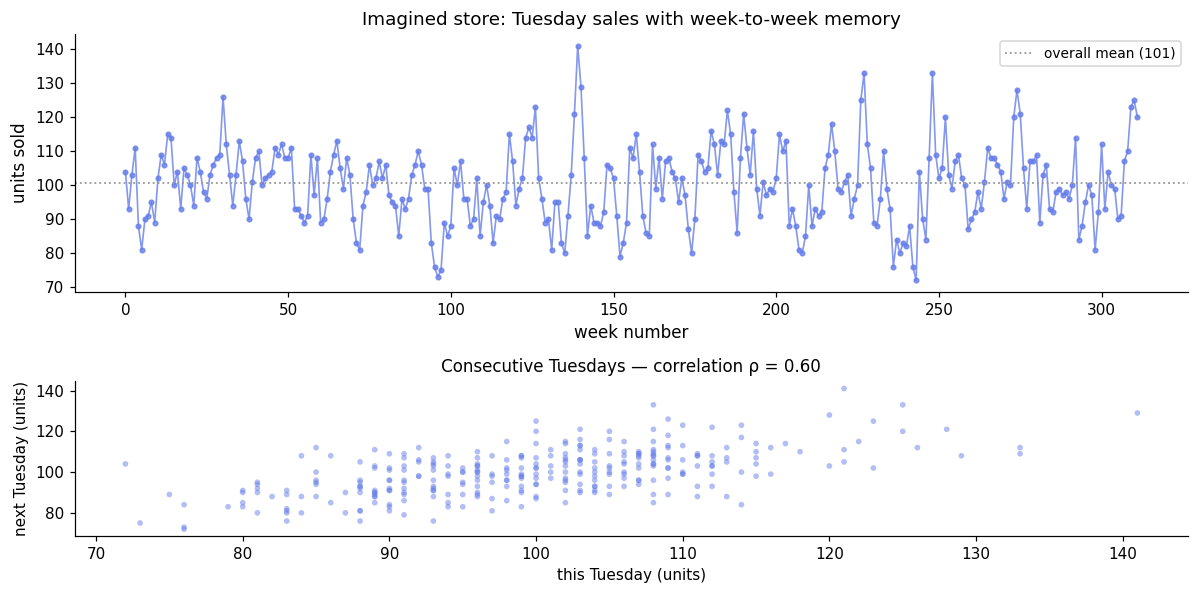

Measured correlation between consecutive Tuesdays: ρ = 0.60
A high Tuesday tends to be followed by another high Tuesday.


In [ ]:

#@title A Plot of such Tuesdays: sales as a time series — do you see patterns or pure noise?
tue = df.loc[df.day_of_week == 'Tuesday'].copy().reset_index(drop=True)
tue['week_number'] = np.arange(len(tue))

n_tue = len(tue)
target_rho = 0.6

rng_bridge = np.random.default_rng(42)
tue_corr = np.zeros(n_tue)
tue_corr[0] = rng_bridge.normal(mu_tue, sig_tue)
for i in range(1, n_tue):
    tue_corr[i] = (mu_tue
                   + target_rho * (tue_corr[i-1] - mu_tue)
                   + np.sqrt(1 - target_rho**2) * rng_bridge.normal(0, sig_tue))
tue_corr = np.round(tue_corr).astype(int)

week_numbers = np.arange(n_tue)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), height_ratios=[3, 1.8])

# --- Top: time series ---
ax = axes[0]
ax.plot(week_numbers, tue_corr, '-o', color=PURPLE, lw=1.1, markersize=3, alpha=0.8)
ax.axhline(mu_tue, color='#999', ls=':', lw=1.2, label=f'overall mean ({mu_tue:.0f})')
ax.set_ylabel('units sold', fontsize=11)
ax.set_title('Imagined store: Tuesday sales with week-to-week memory', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlabel('week number', fontsize=11)

# --- Bottom: lag-1 scatter (this Tuesday vs next Tuesday) ---
ax2 = axes[1]
today = tue_corr[:-1]
next_week = tue_corr[1:]
rho_measured = np.corrcoef(today, next_week)[0, 1]
ax2.scatter(today, next_week, s=14, alpha=0.5, color=PURPLE, edgecolors='none')
ax2.set_xlabel('this Tuesday (units)', fontsize=10)
ax2.set_ylabel('next Tuesday (units)', fontsize=10)
ax2.set_title(f'Consecutive Tuesdays — correlation ρ = {rho_measured:.2f}', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Measured correlation between consecutive Tuesdays: ρ = {rho_measured:.2f}')
print('A high Tuesday tends to be followed by another high Tuesday.')

The scatter plot shows a **clear positive correlation**. If this Tuesday sold more than
usual, next Tuesday tends to as well and vice versa.

This means: **if we just observed today's Tuesday sales, we should be able to make a better
prediction for next Tuesday than simply saying "it will be around μ."** We can update our
belief. To do that, we need a **joint** model of two Tuesdays and a way to **condition**
it on what we observed.

## Two Tuesdays, one joint Gaussian

A bivariate Gaussian over (this Tuesday, next Tuesday) is described by:
- two means: $\mu_1$, $\mu_2$ (both $\approx$ `mu_tue` for us, since both weeks are the
  same regime)
- two standard deviations: $\sigma_1$, $\sigma_2$ (both $\approx$ `sig_tue`)
- one correlation: $\rho$ (how strongly one week predicts the next)

These are packaged into a **mean vector** and a **covariance matrix**:

$$
\boldsymbol{\mu} = \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \qquad
\Sigma = \begin{bmatrix} \sigma_1^2 & \rho\,\sigma_1\,\sigma_2 \\ \rho\,\sigma_1\,\sigma_2 & \sigma_2^2 \end{bmatrix}
$$

Since both Tuesdays share the same regime, $\mu_1 = \mu_2 = \mu$ and
$\sigma_1 = \sigma_2 = \sigma$, which simplifies the matrix to:

$$
\boldsymbol{\mu} = \begin{bmatrix} \mu \\ \mu \end{bmatrix}, \qquad
\Sigma = \begin{bmatrix} \sigma^2 & \rho\,\sigma^2 \\ \rho\,\sigma^2 & \sigma^2 \end{bmatrix}
$$

The magic happens when we **observe** one of them.

## Conditioning

Suppose we observe that this Tuesday sold $x_1 = 115$ units (above average). What do we
now believe about next Tuesday, $x_2$?

The answer comes from the **conditional distribution**, which is itself a Gaussian:

$$
x_2 \mid x_1 \;\sim\; N\Big(\;
  \mu + \rho\,(x_1 - \mu),\;\;
  \sigma^2\,(1 - \rho^2)
\Big)
$$

Two things to notice:

1. **The mean shifts.**
2. **The variance shrinks.**

Observing one variable makes us **more confident** about the other. With $\rho = 0.6$, the variance drops to $64\%$ of its original value.

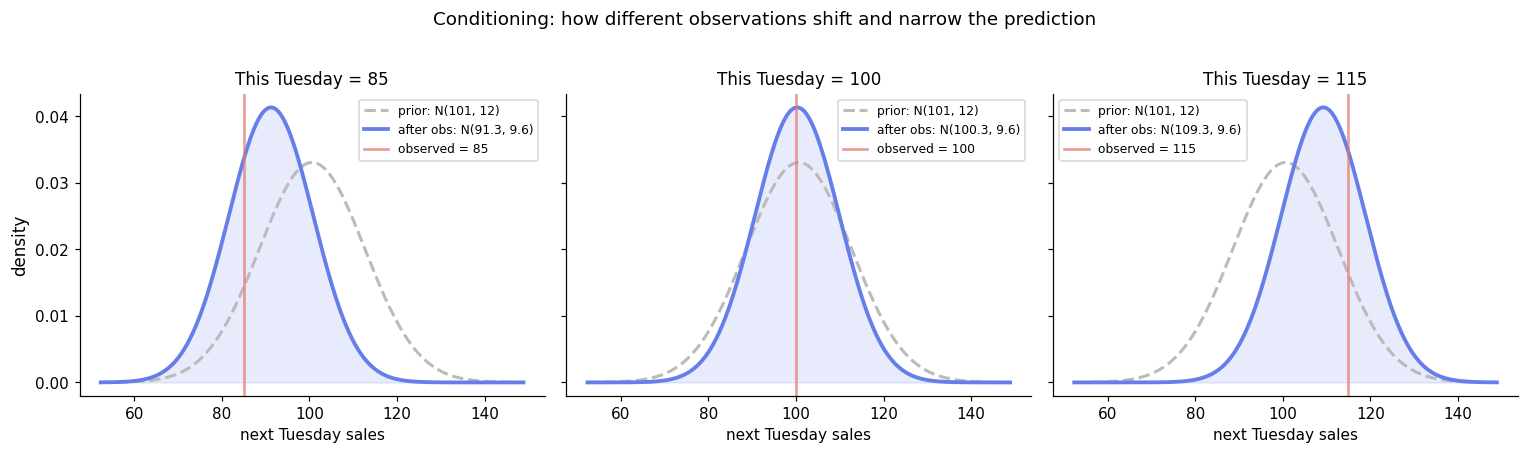

Summary of conditioning:
  Prior (no observation):  N(101, 12)

  After observing 85:  N(91.3, 9.6)
    → mean shifted by -9.4 units toward observation
    → std shrank from 12.1 to 9.6 (variance is now 64% of original)

  After observing 100:  N(100.3, 9.6)
    → mean shifted by -0.4 units toward observation
    → std shrank from 12.1 to 9.6 (variance is now 64% of original)

  After observing 115:  N(109.3, 9.6)
    → mean shifted by +8.6 units toward observation
    → std shrank from 12.1 to 9.6 (variance is now 64% of original)



In [ ]:
#@title Conditioning in action: observe this Tuesday, predict next Tuesday.

# Conditioning in action: observe this Tuesday, predict next Tuesday.

# --- Try three different observations to see the effect ---
observations = [85, 100, 115]
rho_use = rho_measured

xs = np.linspace(mu_tue - 4 * sig_tue, mu_tue + 4 * sig_tue, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, obs in zip(axes, observations):
    # Conditional distribution
    cond_mean = mu_tue + rho_use * (obs - mu_tue)
    cond_std  = sig_tue * np.sqrt(1 - rho_use**2)

    # Prior (before observing)
    ax.plot(xs, gaussian_pdf(xs, mu_tue, sig_tue), color='#bbb', lw=2, ls='--',
            label=f'prior: N({mu_tue:.0f}, {sig_tue:.0f})')
    # Posterior (after observing)
    ax.plot(xs, gaussian_pdf(xs, cond_mean, cond_std), color=PURPLE, lw=2.5,
            label=f'after obs: N({cond_mean:.1f}, {cond_std:.1f})')
    ax.fill_between(xs, gaussian_pdf(xs, cond_mean, cond_std), alpha=0.15, color=PURPLE)
    ax.axvline(obs, color=RED, ls='-', lw=1.8, alpha=0.7, label=f'observed = {obs}')
    ax.set_xlabel('next Tuesday sales', fontsize=10)
    ax.set_title(f'This Tuesday = {obs}', fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_ylabel('density', fontsize=11)
fig.suptitle('Conditioning: how different observations shift and narrow the prediction',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print summary for all three
print('Summary of conditioning:')
print(f'  Prior (no observation):  N({mu_tue:.0f}, {sig_tue:.0f})')
print()
for obs in observations:
    cm = mu_tue + rho_use * (obs - mu_tue)
    cs = sig_tue * np.sqrt(1 - rho_use**2)
    print(f'  After observing {obs}:  N({cm:.1f}, {cs:.1f})')
    print(f'    → mean shifted by {cm - mu_tue:+.1f} units toward observation')
    print(f'    → std shrank from {sig_tue:.1f} to {cs:.1f} (variance is now {100*(1-rho_use**2):.0f}% of original)')
    print()

In every case, the solid bell is taller and narrower than the dashed one. That is conditioning at work: **data always helps.**

This is the entire mechanism of a Gaussian Process in miniature:
- You start with a **prior** belief (the dashed bell — what you'd guess with no data).
- You **observe** a value.
- Conditioning gives you a **posterior** (the solid bell) — narrower and shifted toward the data.

A GP does this simultaneously for many points. Let's see that now.

## From 2 Tuesdays to 20: where confidence bands come from

So far we conditioned on one observation to predict one future value. Now imagine modelling
**20 consecutive Tuesdays jointly** meaning we write down a single Gaussian distribution
over all 20 weeks at once. We observe sales on *some* of those weeks and **condition** to get a prediction at each unobserved week.

The result: a predicted mean and a predicted standard deviation at every unobserved week.
$$
\mathbf{x}_{\text{unobserved}} \mid \mathbf{x}_{\text{observed}} \;\sim\; N\Big(\;\boldsymbol{\mu}_{\text{cond}},\;\; \Sigma_{\text{cond}}\Big)
$$

When we plot those, the ±2σ band around the mean shows our **uncertainty**: it is narrow
near weeks where we have data (the observation pinned down the value) and wide in the gaps
(no data, so we are less sure).

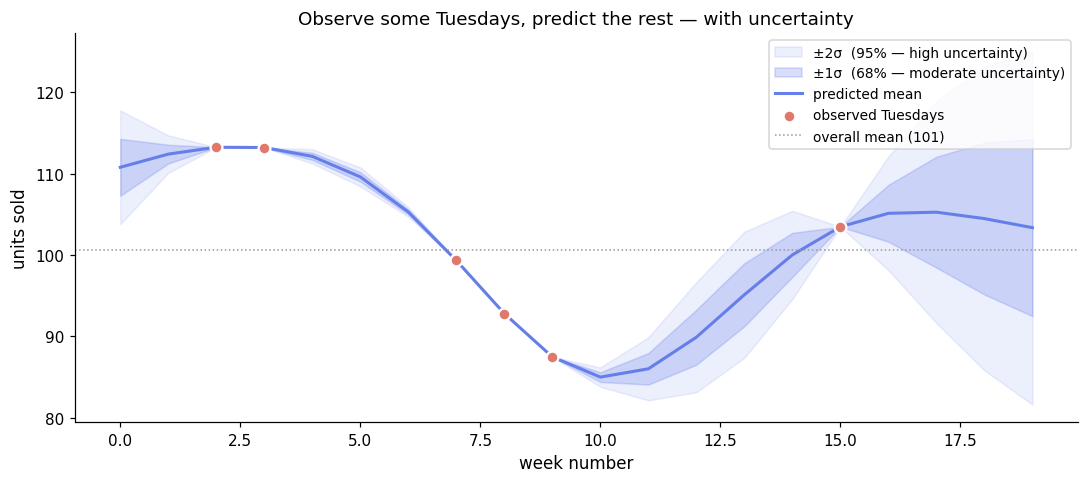

What to notice:
  • The shaded bands represent UNCERTAINTY — how sure we are about the prediction.
  • Near observed weeks (red dots): bands are narrow → we are confident.
  • In gaps with no data (e.g. weeks 4–6, 10–14): bands widen → we are less sure.
  • The predicted mean bends toward observations → same shift you saw in 2D above.

  This IS a Gaussian Process prediction. You just did it by hand.


In [ ]:
#@title 20 Tuesdays: observe some, predict the rest.
# 20 Tuesdays: observe some, predict the rest — the GP-style picture.
n_weeks = 20
weeks = np.arange(n_weeks)

# Build covariance matrix: nearby weeks are correlated, distant ones less so.
# This is a squared-exponential (RBF) kernel — the same one you will meet in the GP notebook.
length_scale = 3.0  # "memory" in weeks — controls how smooth the trajectories are
K = sig_tue**2 * np.exp(-0.5 * ((weeks[:, None] - weeks[None, :]) / length_scale)**2)

# Suppose we observed these weeks
observed_idx = np.array([2, 3, 7, 8, 9, 15])
unobserved_idx = np.array([i for i in range(n_weeks) if i not in observed_idx])

# Simulate observed values (one draw from the joint Gaussian)
rng_gp = np.random.default_rng(42)
all_sales = rng_gp.multivariate_normal(np.full(n_weeks, mu_tue), K)
observed_vals = all_sales[observed_idx]

# --- Conditioning (multivariate version of the same formula from Cell D) ---
K_oo = K[np.ix_(observed_idx, observed_idx)]       # covariance among observed weeks
K_uu = K[np.ix_(unobserved_idx, unobserved_idx)]   # covariance among unobserved weeks
K_uo = K[np.ix_(unobserved_idx, observed_idx)]      # cross-covariance

mu_obs = np.full(len(observed_idx), mu_tue)
mu_unobs = np.full(len(unobserved_idx), mu_tue)

K_oo_inv = np.linalg.inv(K_oo + 1e-6 * np.eye(len(observed_idx)))
cond_mu  = mu_unobs + K_uo @ K_oo_inv @ (observed_vals - mu_obs)
cond_cov = K_uu - K_uo @ K_oo_inv @ K_uo.T
cond_std = np.sqrt(np.diag(cond_cov))

# Assemble full prediction (observed weeks are exact, unobserved are predicted)
pred_mu  = np.full(n_weeks, np.nan)
pred_std = np.full(n_weeks, np.nan)
pred_mu[observed_idx] = observed_vals
pred_mu[unobserved_idx] = cond_mu
pred_std[observed_idx] = 0.0
pred_std[unobserved_idx] = cond_std

# --- The signature GP-style plot ---
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(weeks, pred_mu - 2 * pred_std, pred_mu + 2 * pred_std,
                color=PURPLE, alpha=0.12, label='±2σ  (95% — high uncertainty)')
ax.fill_between(weeks, pred_mu - pred_std, pred_mu + pred_std,
                color=PURPLE, alpha=0.25, label='±1σ  (68% — moderate uncertainty)')
ax.plot(weeks, pred_mu, color=PURPLE, lw=2, label='predicted mean')
ax.scatter(observed_idx, observed_vals, color=RED, s=60, zorder=5,
           edgecolors='white', linewidths=1.5, label='observed Tuesdays')
ax.axhline(mu_tue, color='#999', ls=':', lw=1, label=f'overall mean ({mu_tue:.0f})')

ax.set_xlabel('week number', fontsize=11)
ax.set_ylabel('units sold', fontsize=11)
ax.set_title('Observe some Tuesdays, predict the rest — with uncertainty', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('What to notice:')
print('  • The shaded bands represent UNCERTAINTY — how sure we are about the prediction.')
print('  • Near observed weeks (red dots): bands are narrow → we are confident.')
print('  • In gaps with no data (e.g. weeks 4–6, 10–14): bands widen → we are less sure.')
print('  • The predicted mean bends toward observations → same shift you saw in 2D above.')
print()
print('  This IS a Gaussian Process prediction. You just did it by hand.')

## What you just explored

That plot, a predicted mean line with shaded uncertainty bands that narrow near data and
widen away from it, is **the** canonical Gaussian Process picture. You built it using only
two ideas from this notebook:

1. **A multivariate Gaussian** with a covariance matrix that links nearby weeks (the
   "length scale" controls how far the memory reaches exactly the kernel parameter you
   will tune in the GP notebook).
2. **Conditioning** on observed values to update the prediction at unobserved weeks. The
   same formula from the two-Tuesday case, just applied to bigger matrices.


You now have the vocabulary and the visual intuition. The next notebook will make it
precise. 🚀